# Network Flow Inference Notebook
XGBoost inference on labeled flow CSVs with optional ground truth evaluation.

**Pipeline:** Load → Preprocess → Infer → Evaluate vs ground truth → Visualize

In [11]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..') # Move up one level to the project root

print("Corrected Working Directory:", os.getcwd())

Corrected Working Directory: /home/cpre560/Desktop/IDS-ML


In [12]:
import sys
print(sys.executable)

/home/cpre560/miniconda3/envs/cpre560/bin/python


In [13]:
# === CELL 1: Imports & Paths ===
import xgboost as xgb
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────
MODEL_PATH      = 'models/baseline_xgboost.json'
ARTIFACTS_PATH  = 'models/preprocessing_info.pkl'
RENAME_MAP_PATH = 'src/preprocessing/rename_map.pkl'  # fixed path
CSV_PATH        = 'data/flows.csv'                    # VM-generated flows
OUT_DIR         = Path('output')
if not OUT_DIR.exists():
    raise FileNotFoundError(f'Output folder not found: {OUT_DIR.absolute()}\nMake sure you are running from the project root.')

# Ground truth column — set to None to skip GT evaluation
GROUND_TRUTH_COL = 'Label'
CONF_THRESHOLD   = 0.90

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})
PALETTE = {'BENIGN': '#1D9E75', 'DDoS': '#D85A30', 'other': '#7F77DD'}
print('Imports OK')
print(f'   CSV : {CSV_PATH}')
print(f'   Out : {OUT_DIR.absolute()}')

Imports OK
   CSV : data/flows.csv
   Out : /home/cpre560/Desktop/IDS-ML/output


In [14]:
# === CELL 2: Load Model & Artifacts ===
model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

with open(ARTIFACTS_PATH, 'rb') as f:
    artifacts = pickle.load(f)
le_target    = artifacts['target_encoder']
feature_cols = artifacts['feature_columns']

with open(RENAME_MAP_PATH, 'rb') as f:
    rename_map = pickle.load(f)

print(f'Model loaded')
print(f'Classes ({len(le_target.classes_)}) : {list(le_target.classes_)}')
print(f'Feature cols : {len(feature_cols)}')

Model loaded
Classes (12) : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � XSS']
Feature cols : 78


/home/cpre560/miniconda3/envs/cpre560/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
# === CELL 3: Load & Preprocess CSV ===
df_raw = pd.read_csv(CSV_PATH)
df_raw.columns = df_raw.columns.str.strip()
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw.rename(columns=rename_map, inplace=True)

# 1. CICIDS2017 duplicate header fix
if 'Fwd Header Length' in df_raw.columns:
    df_raw['Fwd Header Length.1'] = df_raw['Fwd Header Length']

# 2. BULLETPROOF FEATURE ALIGNMENT
# If the CSV is missing columns the model needs, add them as 0
missing = [c for c in feature_cols if c not in df_raw.columns]
if missing:
    print(f"[*] Note: Padding {len(missing)} missing features with 0 (e.g., Bulk features)")
    for col in missing:
        df_raw[col] = 0

# Stash ground truth BEFORE any row drops
has_gt = GROUND_TRUTH_COL is not None and GROUND_TRUTH_COL in df_raw.columns
if has_gt:
    gt_series = df_raw[GROUND_TRUTH_COL].str.strip()
else:
    gt_series = None
    print(f"WARNING: '{GROUND_TRUTH_COL}' not found — skipping GT evaluation")

# Now drop rows with NaNs only in the features we actually have
df_raw.dropna(subset=feature_cols, inplace=True)
X = df_raw[feature_cols]

# Ensure column order matches the model's training order exactly
X = X[feature_cols]

if has_gt:
    y_true = gt_series.loc[df_raw.index]

print(f'Loaded {len(X):,} flows  |  {X.shape[1]} features')

[*] Note: Padding 8 missing features with 0 (e.g., Bulk features)
Loaded 117,285 flows  |  78 features


In [16]:
# === CELL 4: Run Inference ===
y_pred       = model.predict(X)
y_pred_proba = model.predict_proba(X)
y_pred_label = le_target.inverse_transform(y_pred)
confidence   = y_pred_proba.max(axis=1)

results = pd.DataFrame(index=df_raw.index)
results['Predicted_Label']    = y_pred_label
results['Predicted_Class_ID'] = y_pred
results['Confidence']         = confidence.round(4)

if has_gt:
    results['Ground_Truth'] = y_true
    results['Correct']      = results['Predicted_Label'] == results['Ground_Truth']

for i, cls in enumerate(le_target.classes_):
    results[f'Prob_{cls}'] = y_pred_proba[:, i].round(4)

results.to_csv(OUT_DIR / 'inference_results.csv', index=False)
print(f'{len(results):,} predictions saved → output/inference_results.csv')
print('\nPrediction distribution:')
display(results['Predicted_Label'].value_counts().rename_axis('Predicted').reset_index(name='Count'))

117,285 predictions saved → output/inference_results.csv

Prediction distribution:


,Predicted,Count
0,BENIGN,117228
1,FTP-Patator,29
2,DoS Hulk,28


In [17]:
# === CELL 5: Ground Truth Evaluation ===
if not has_gt:
    print('No ground truth — skipping evaluation.')
else:
    y_tv = results['Ground_Truth']
    y_pv = results['Predicted_Label']

    acc      = accuracy_score(y_tv, y_pv)
    f1_macro = f1_score(y_tv, y_pv, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_tv, y_pv, average='weighted', zero_division=0)
    prec     = precision_score(y_tv, y_pv, average='macro', zero_division=0)
    rec      = recall_score(y_tv,    y_pv, average='macro', zero_division=0)

    print('=' * 50)
    print(f'  Accuracy       : {acc*100:.2f}%')
    print(f'  Macro F1       : {f1_macro*100:.2f}%')
    print(f'  Weighted F1    : {f1_wt*100:.2f}%')
    print(f'  Macro Precision: {prec*100:.2f}%')
    print(f'  Macro Recall   : {rec*100:.2f}%')
    print('=' * 50)
    print()
    print(classification_report(y_tv, y_pv, zero_division=0))

    misclassified = results[~results['Correct']]
    misclassified.to_csv(OUT_DIR / 'misclassified_flows.csv', index=False)
    print(f'Misclassified : {len(misclassified):,} / {len(results):,}  '
          f'({len(misclassified)/len(results)*100:.2f}%)')
    print('Saved → output/misclassified_flows.csv')

  Accuracy       : 99.95%
  Macro F1       : 33.33%
  Weighted F1    : 99.98%
  Macro Precision: 33.33%
  Macro Recall   : 33.32%

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    117285
    DoS Hulk       0.00      0.00      0.00         0
 FTP-Patator       0.00      0.00      0.00         0

    accuracy                           1.00    117285
   macro avg       0.33      0.33      0.33    117285
weighted avg       1.00      1.00      1.00    117285

Misclassified : 57 / 117,285  (0.05%)
Saved → output/misclassified_flows.csv


In [18]:
# === CELL 6: Per-Class Performance Table (sortable) ===
if not has_gt:
    print('No ground truth — skipping.')
else:
    from IPython.display import HTML
    y_tv = results['Ground_Truth']
    y_pv = results['Predicted_Label']
    report = classification_report(y_tv, y_pv, output_dict=True, zero_division=0)

    rows = []
    for cls in sorted(y_tv.unique()):
        gt_c  = int((y_tv == cls).sum())
        pd_c  = int((y_pv == cls).sum())
        corr  = int(((y_tv == cls) & (y_pv == cls)).sum())
        misc  = gt_c - corr
        r = report.get(cls, {})
        rows.append({
            'Attack Class':    cls,
            'GT Count':        gt_c,
            'Predicted Count': pd_c,
            'Correct':         corr,
            'Misclassified':   misc,
            '% Correct':       round(corr/gt_c*100 if gt_c else 0, 2),
            '% Misclassified': round(misc/gt_c*100 if gt_c else 0, 2),
            'Precision':       round(r.get('precision',0)*100, 2),
            'Recall':          round(r.get('recall',0)*100, 2),
            'F1 Score':        round(r.get('f1-score',0)*100, 2),
        })

    perf_df = pd.DataFrame(rows)
    perf_df.to_csv(OUT_DIR / 'per_class_performance.csv', index=False)
    print('Saved → output/per_class_performance.csv')
    display(perf_df.style
            .background_gradient(subset=['% Correct','Precision','Recall','F1 Score'], cmap='RdYlGn')
            .format('{:.2f}', subset=['% Correct','% Misclassified','Precision','Recall','F1 Score']))

Saved → output/per_class_performance.csv


,Attack Class,GT Count,Predicted Count,Correct,Misclassified,% Correct,% Misclassified,Precision,Recall,F1 Score
0,BENIGN,117285,117228,117228,57,99.95,0.05,100.00,99.95,99.98


/tmp/ipykernel_5995/2108438538.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(groups, labels=classes, patch_artist=True, zorder=2)


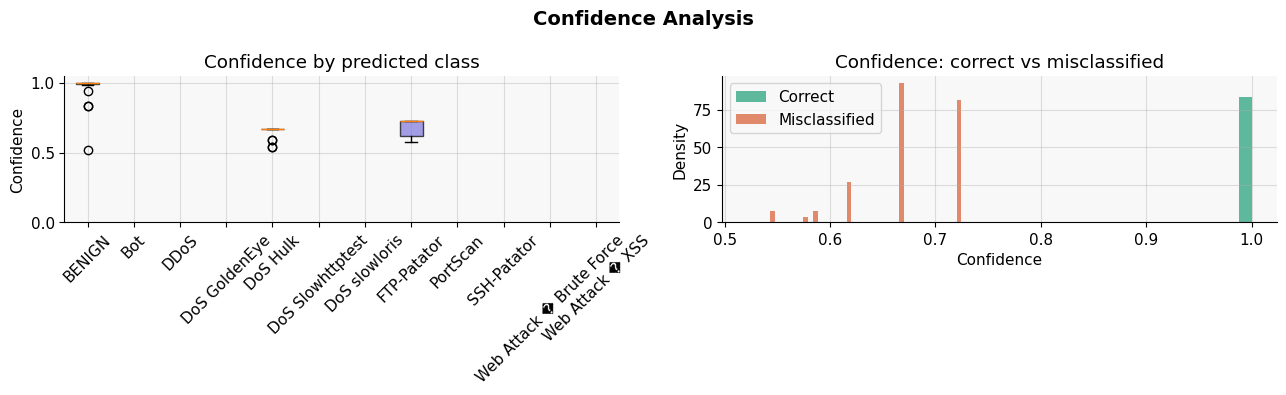

In [19]:
# === CELL 7: Confidence Analysis ===
classes = list(le_target.classes_)
colors  = [PALETTE.get(c, PALETTE['other']) for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Confidence Analysis', fontsize=14, fontweight='bold')

groups = [results.loc[results['Predicted_Label']==c, 'Confidence'].values for c in classes]
bp = axes[0].boxplot(groups, labels=classes, patch_artist=True, zorder=2)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Confidence by predicted class')
axes[0].set_ylabel('Confidence')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=45)

if has_gt:
    axes[1].hist(results.loc[ results['Correct'],  'Confidence'], bins=40,
                 alpha=0.7, color='#1D9E75', label='Correct',       density=True)
    axes[1].hist(results.loc[~results['Correct'], 'Confidence'], bins=40,
                 alpha=0.7, color='#D85A30', label='Misclassified', density=True)
    axes[1].legend()
    axes[1].set_title('Confidence: correct vs misclassified')
else:
    axes[1].hist(results['Confidence'], bins=40, color='#7F77DD', alpha=0.8, density=True)
    axes[1].set_title('Overall confidence distribution')
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

Flows below 90% confidence: 60 (0.05%)


Predicted_Label
FTP-Patator    29
DoS Hulk       28
BENIGN          3
Name: count, dtype: int64

Correct in low-conf set: 3/60 (5.0%)


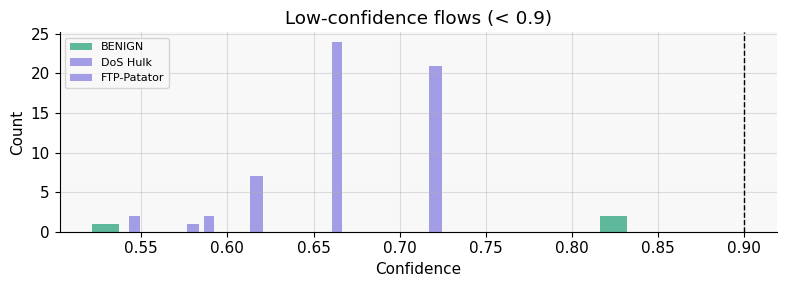

Saved → output/low_confidence_flows.csv


In [20]:
# === CELL 8: Low-Confidence Inspection ===
low_conf = results[results['Confidence'] < CONF_THRESHOLD].copy()
print(f'Flows below {CONF_THRESHOLD*100:.0f}% confidence: '
      f'{len(low_conf):,} ({len(low_conf)/len(results)*100:.2f}%)')

if len(low_conf) > 0:
    display(low_conf['Predicted_Label'].value_counts())
    if has_gt:
        lc_corr = low_conf['Correct'].sum()
        print(f'Correct in low-conf set: {lc_corr}/{len(low_conf)} '
              f'({lc_corr/len(low_conf)*100:.1f}%)')

    fig, ax = plt.subplots(figsize=(8, 3))
    for cls, color in zip(classes, colors):
        mask = low_conf['Predicted_Label'] == cls
        if mask.sum() > 0:
            ax.hist(low_conf.loc[mask, 'Confidence'], bins=20,
                    alpha=0.7, color=color, label=cls)
    ax.axvline(CONF_THRESHOLD, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Low-confidence flows (< {CONF_THRESHOLD})')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'plot_low_confidence.png', dpi=150, bbox_inches='tight')
    plt.show()

    low_conf.to_csv(OUT_DIR / 'low_confidence_flows.csv', index=False)
    print('Saved → output/low_confidence_flows.csv')
else:
    print('No low-confidence flows — model is highly confident on all samples.')

In [ ]:
# === CELL 9: Summary ===
print('=' * 55)
print('  INFERENCE RUN SUMMARY')
print('=' * 55)
print(f'  Input file      : {CSV_PATH}')
print(f'  Total flows     : {len(results):,}')
print(f'  Low-conf flows  : {len(results[results["Confidence"] < CONF_THRESHOLD]):,} (< {CONF_THRESHOLD})')
print(f'  Mean confidence : {results["Confidence"].mean():.4f}')
print()
for cls in classes:
    n = (results['Predicted_Label'] == cls).sum()
    print(f'  {cls:<20} : {n:>8,}  ({n/len(results)*100:.2f}%)')
print()
if has_gt:
    print(f'  Accuracy     : {accuracy_score(results["Ground_Truth"], results["Predicted_Label"])*100:.2f}%')
    print(f'  Macro F1     : {f1_score(results["Ground_Truth"], results["Predicted_Label"], average="macro", zero_division=0)*100:.2f}%')
    print(f'  Misclassified: {(~results["Correct"]).sum():,}')
print('=' * 55)
print()
print('Output files saved to output/')

  INFERENCE RUN SUMMARY
  Input file      : data/flows.csv
  Total flows     : 117,285
  Low-conf flows  : 60 (< 0.9)
  Mean confidence : 0.9952

  BENIGN               :  117,228  (99.95%)
  Bot                  :        0  (0.00%)
  DDoS                 :        0  (0.00%)
  DoS GoldenEye        :        0  (0.00%)
  DoS Hulk             :       28  (0.02%)
  DoS Slowhttptest     :        0  (0.00%)
  DoS slowloris        :        0  (0.00%)
  FTP-Patator          :       29  (0.02%)
  PortScan             :        0  (0.00%)
  SSH-Patator          :        0  (0.00%)
  Web Attack � Brute Force :        0  (0.00%)
  Web Attack � XSS     :        0  (0.00%)

  Accuracy     : 99.95%
